In [1]:
%load_ext autoreload
%autoreload 2
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch

from tqdm.notebook import tqdm

from scFM_density_estimation.models import *
from scFM_density_estimation.datamodules import *
from scFM_density_estimation.utils import *

In [2]:
def prepare_batch(X, C, num_classes, batch_size, device):
    indices = np.random.randint(X.shape[0], size=batch_size)
    x1 = torch.from_numpy(X[indices]).float().to(device)
    cond = torch.nn.functional.one_hot(torch.from_numpy(C[indices]).long(),
                                       num_classes=num_classes).float().to(device)
    return x1, cond

def prepare_val_batch(X, C, num_classes, device):
    x1 = torch.from_numpy(X).float().to(device)
    cond = torch.nn.functional.one_hot(torch.from_numpy(C).long(),
                                       num_classes=num_classes).float().to(device)
    return x1, cond

def weighted_wasserstein(X, C, num_classes, model):
    ws_dist = 0
    for condition in np.unique(C):
        x1 = torch.from_numpy(X[C == condition]).float().to(model.device)
        cond = torch.nn.functional.one_hot(torch.from_numpy(C[C == condition]).long(),
                                       num_classes=num_classes).float().to(model.device)
        generated_samples = model.run_simulation(x1, cond, n_steps=100)
        ws_dist += wasserstein(x1, generated_samples) * np.sum(C == condition)

    return ws_dist / C.shape[0]

In [3]:
# n_genes = 64
adata = sc.read_h5ad("./data/pbmc3k.h5ad")
# sc.pp.highly_variable_genes(adata, n_top_genes=n_genes)
# adata = adata[:, adata.var.highly_variable]
# adata.write_h5ad("./data/pbmc3k_processed.h5ad")

In [4]:
# datamodule = scFMDataModule(
#     adata_path="./data/pbmc3k.h5ad",
#     label_key="louvain",
#     batch_size=256,
#     val_split=0.01,
#     test_split=0.01,
#     n_conds=8
# )
# datamodule.setup()
# train_dataloader = datamodule.train_dataloader()

In [6]:
X = adata.obsm["X_pca"][:, :10]
C = adata.obs["louvain"].cat.codes.values.copy()

  0%|          | 0/300000 [00:00<?, ?it/s]

Step 5000, EMA Loss: 2.348
Step 5000, Weighted Wasserstein distance: 2.995
Step 10000, EMA Loss: 2.228
Step 10000, Weighted Wasserstein distance: 2.998
Step 15000, EMA Loss: 2.205
Step 15000, Weighted Wasserstein distance: 2.991
Step 20000, EMA Loss: 2.191
Step 20000, Weighted Wasserstein distance: 2.967
Step 25000, EMA Loss: 2.173
Step 25000, Weighted Wasserstein distance: 2.911
Step 30000, EMA Loss: 2.158
Step 30000, Weighted Wasserstein distance: 2.818
Step 35000, EMA Loss: 2.147
Step 35000, Weighted Wasserstein distance: 2.883
Step 40000, EMA Loss: 2.130
Step 40000, Weighted Wasserstein distance: 2.807
Step 45000, EMA Loss: 2.129
Step 45000, Weighted Wasserstein distance: 2.736
Step 50000, EMA Loss: 2.117
Step 50000, Weighted Wasserstein distance: 2.745


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


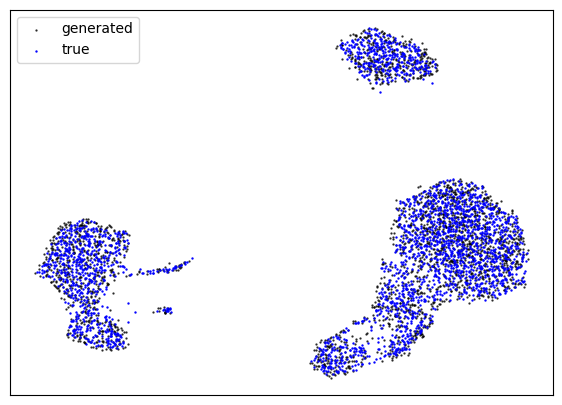

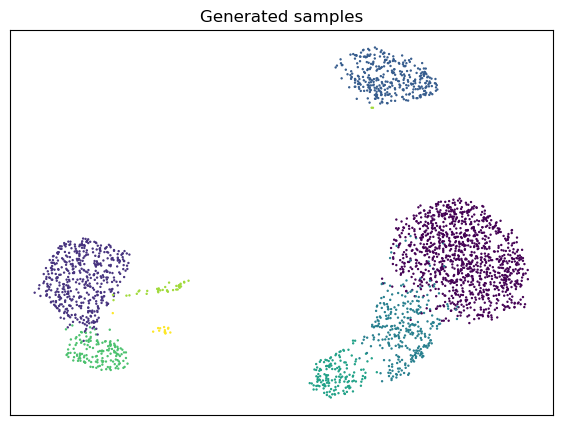

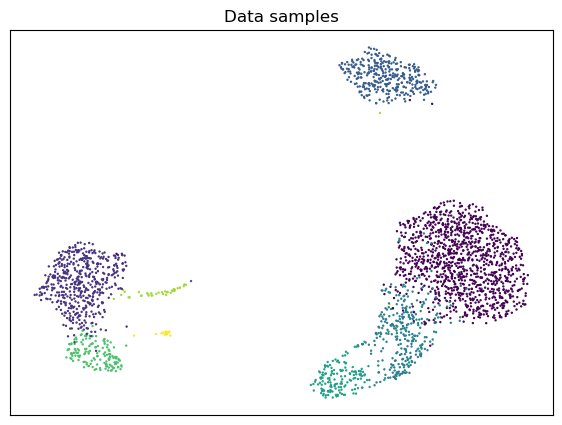

Step 55000, EMA Loss: 2.105
Step 55000, Weighted Wasserstein distance: 2.762
Step 60000, EMA Loss: 2.099
Step 60000, Weighted Wasserstein distance: 2.761
Step 65000, EMA Loss: 2.094
Step 65000, Weighted Wasserstein distance: 2.715
Step 70000, EMA Loss: 2.090
Step 70000, Weighted Wasserstein distance: 2.728
Step 75000, EMA Loss: 2.081
Step 75000, Weighted Wasserstein distance: 2.711
Step 80000, EMA Loss: 2.080
Step 80000, Weighted Wasserstein distance: 2.637
Step 85000, EMA Loss: 2.068
Step 85000, Weighted Wasserstein distance: 2.667
Step 90000, EMA Loss: 2.068
Step 90000, Weighted Wasserstein distance: 2.736
Step 95000, EMA Loss: 2.059
Step 95000, Weighted Wasserstein distance: 2.678
Step 100000, EMA Loss: 2.053
Step 100000, Weighted Wasserstein distance: 2.692


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


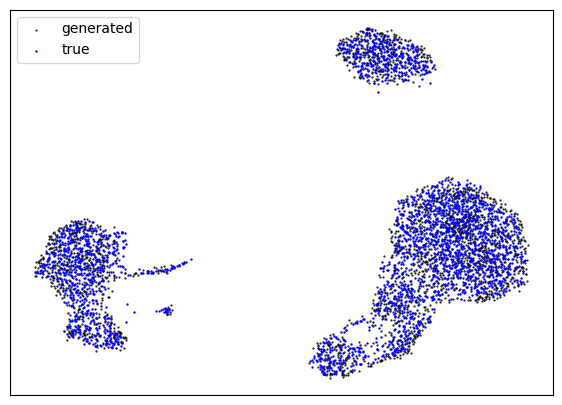

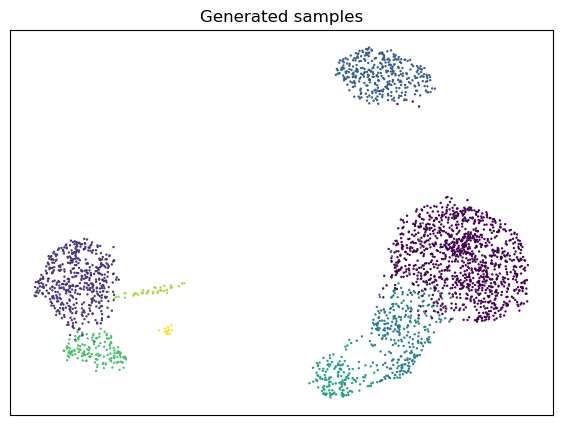

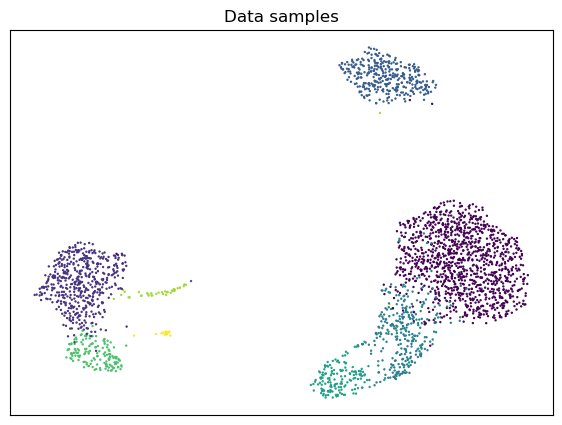

Step 105000, EMA Loss: 2.046
Step 105000, Weighted Wasserstein distance: 2.640
Step 110000, EMA Loss: 2.046
Step 110000, Weighted Wasserstein distance: 2.606
Step 115000, EMA Loss: 2.045
Step 115000, Weighted Wasserstein distance: 2.591
Step 120000, EMA Loss: 2.042
Step 120000, Weighted Wasserstein distance: 2.653
Step 125000, EMA Loss: 2.038
Step 125000, Weighted Wasserstein distance: 2.599
Step 130000, EMA Loss: 2.036
Step 130000, Weighted Wasserstein distance: 2.599
Step 135000, EMA Loss: 2.036
Step 135000, Weighted Wasserstein distance: 2.631
Step 140000, EMA Loss: 2.024
Step 140000, Weighted Wasserstein distance: 2.642
Step 145000, EMA Loss: 2.031
Step 145000, Weighted Wasserstein distance: 2.584
Step 150000, EMA Loss: 2.025
Step 150000, Weighted Wasserstein distance: 2.592


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


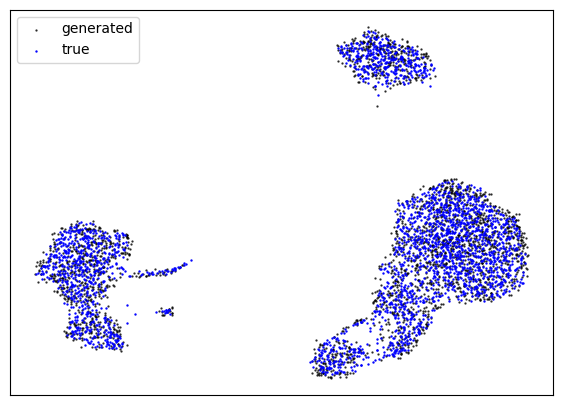

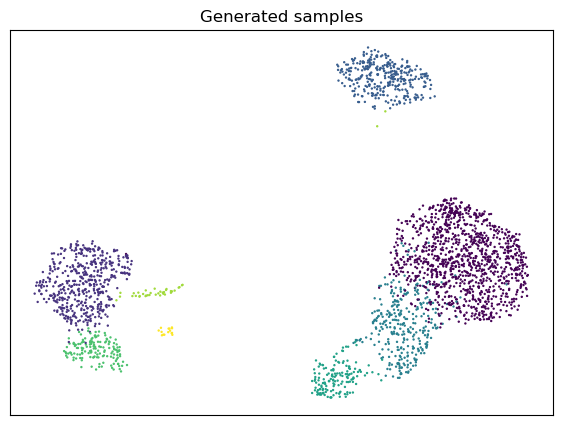

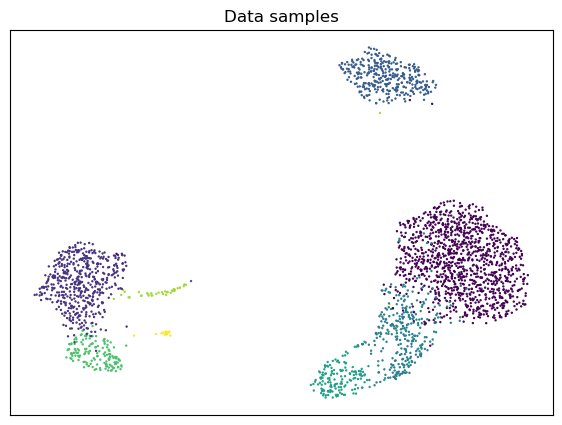

Step 155000, EMA Loss: 2.021
Step 155000, Weighted Wasserstein distance: 2.677
Step 160000, EMA Loss: 2.014
Step 160000, Weighted Wasserstein distance: 2.584
Step 165000, EMA Loss: 2.017
Step 165000, Weighted Wasserstein distance: 2.633
Step 170000, EMA Loss: 2.017
Step 170000, Weighted Wasserstein distance: 2.564
Step 175000, EMA Loss: 2.013
Step 175000, Weighted Wasserstein distance: 2.587
Step 180000, EMA Loss: 2.007
Step 180000, Weighted Wasserstein distance: 2.555
Step 185000, EMA Loss: 2.007
Step 185000, Weighted Wasserstein distance: 2.610
Step 190000, EMA Loss: 2.002
Step 190000, Weighted Wasserstein distance: 2.571
Step 195000, EMA Loss: 1.998
Step 195000, Weighted Wasserstein distance: 2.540
Step 200000, EMA Loss: 1.995
Step 200000, Weighted Wasserstein distance: 2.592


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


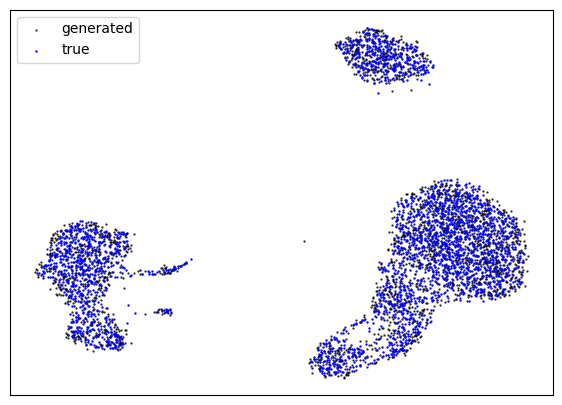

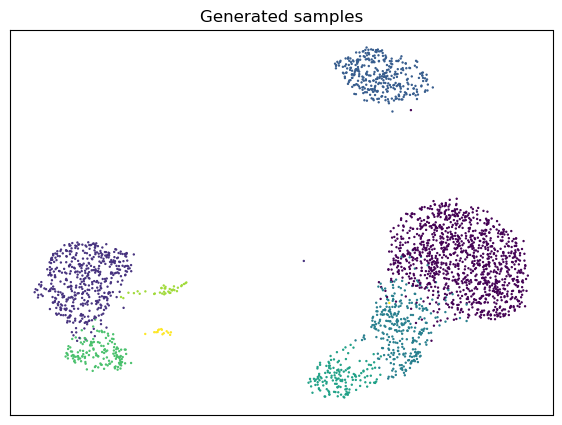

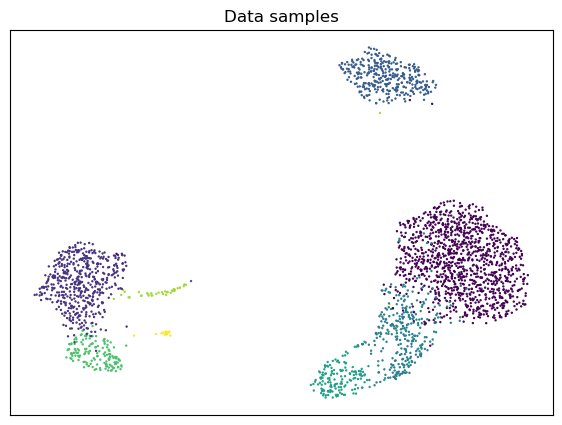

Step 205000, EMA Loss: 1.998
Step 205000, Weighted Wasserstein distance: 2.473
Step 210000, EMA Loss: 1.998
Step 210000, Weighted Wasserstein distance: 2.606
Step 215000, EMA Loss: 1.995
Step 215000, Weighted Wasserstein distance: 2.571
Step 220000, EMA Loss: 1.990
Step 220000, Weighted Wasserstein distance: 2.610
Step 225000, EMA Loss: 1.992
Step 225000, Weighted Wasserstein distance: 2.575
Step 230000, EMA Loss: 1.989
Step 230000, Weighted Wasserstein distance: 2.525
Step 235000, EMA Loss: 1.982
Step 235000, Weighted Wasserstein distance: 2.497
Step 240000, EMA Loss: 1.986
Step 240000, Weighted Wasserstein distance: 2.479
Step 245000, EMA Loss: 1.980
Step 245000, Weighted Wasserstein distance: 2.623
Step 250000, EMA Loss: 1.983
Step 250000, Weighted Wasserstein distance: 2.519


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


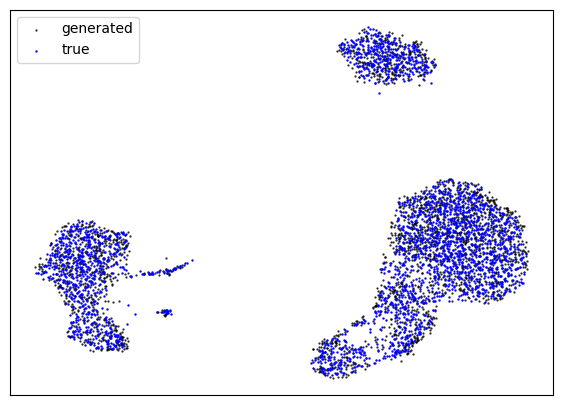

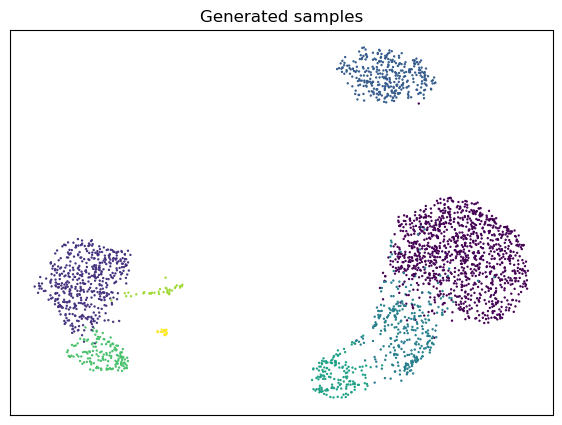

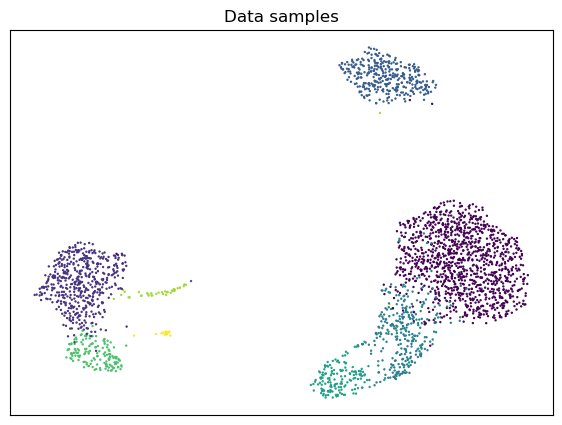

Step 255000, EMA Loss: 1.983
Step 255000, Weighted Wasserstein distance: 2.488
Step 260000, EMA Loss: 1.972
Step 260000, Weighted Wasserstein distance: 2.588
Step 265000, EMA Loss: 1.978
Step 265000, Weighted Wasserstein distance: 2.503
Step 270000, EMA Loss: 1.973
Step 270000, Weighted Wasserstein distance: 2.532
Step 275000, EMA Loss: 1.971
Step 275000, Weighted Wasserstein distance: 2.478
Step 280000, EMA Loss: 1.972
Step 280000, Weighted Wasserstein distance: 2.542
Step 285000, EMA Loss: 1.973
Step 285000, Weighted Wasserstein distance: 2.544
Step 290000, EMA Loss: 1.969
Step 290000, Weighted Wasserstein distance: 2.541
Step 295000, EMA Loss: 1.968
Step 295000, Weighted Wasserstein distance: 2.511
Step 300000, EMA Loss: 1.966
Step 300000, Weighted Wasserstein distance: 2.526


/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


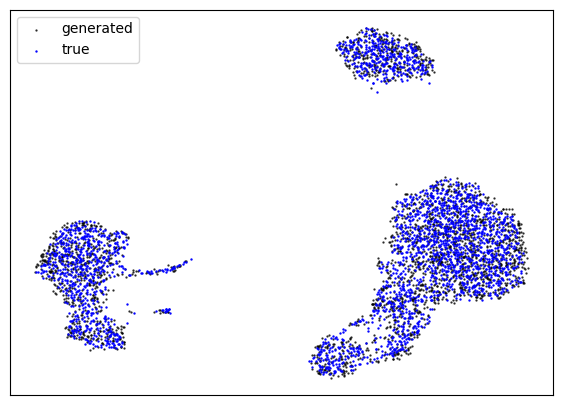

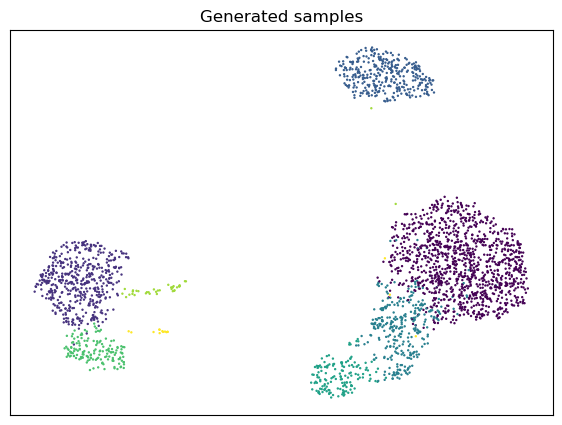

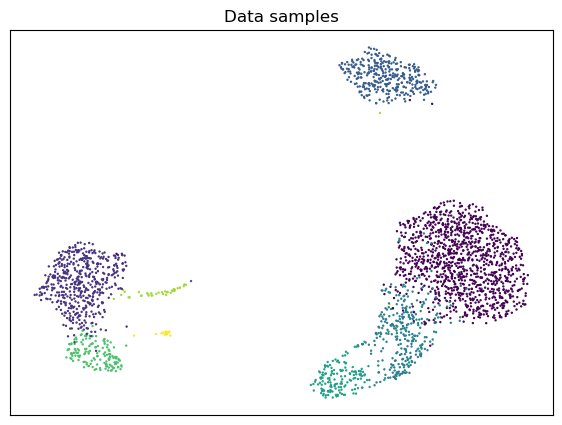

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
cond_dim = 8
dim = 10
alpha = 0.999
ema_loss = None
use_ot_sampler = False
model = ConditionalFlowMatching(input_dim=dim, hidden_dims=[256, 256, 256],
                                   cond_dim=cond_dim, use_encoder=False,
                                   use_ot_sampler=use_ot_sampler).to(device)
optimizer = model.configure_optimizers()

# for epoch in tqdm(range(200)):
#     for batch in train_dataloader:
#         optimizer.zero_grad()
    
#         x1, cond = batch
#         loss = model.shared_step(x1.to(device), cond.to(device))

for k in tqdm(range(300000)):
    optimizer.zero_grad()

    x1, cond = prepare_batch(X, C, cond_dim, batch_size, device)
    loss = model.shared_step(x1, cond)
    
    loss.backward()
    optimizer.step()

    if ema_loss is None:
        ema_loss = loss.item()
    else:
        ema_loss = alpha * ema_loss + (1 - alpha) * loss.item()

    # if (epoch + 1) % 100 == 0:
    #     print(f"Epoch {epoch+1}, EMA Loss: {ema_loss:.3f}") 

    if (k + 1) % 5000 == 0:
        ws_dist = weighted_wasserstein(X, C, cond_dim, model)
        print(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")
        print(f"Step {k+1}, Weighted Wasserstein distance: {ws_dist:.3f}")

    # if (epoch + 1) % 200 == 0:
    #     x1, cond = train_dataloader.dataset[:]
    if (k + 1) % 50000 == 0:
        x1, cond = prepare_val_batch(X, C, cond_dim, device)

        generated_samples = model.run_simulation(x1.to(device), cond.to(device), n_steps=100)

        model.get_umap_reducer()
        data_umap = model.reducer.fit_transform(x1.cpu().numpy())
        generated_umap = model.reducer.transform(generated_samples.cpu().numpy())
        
        plot_simulation(generated_umap, data_umap,
                        np.argmax(cond.cpu().numpy(), axis=1),
                        size=0.5, plot_size=(7, 5))

Best result of 4x1024 no ot: EMA - 1.335, WS - 8.110 \
Best result of 4x1024 ot: EMA - 0.854, WS - 8.380 \
Best result of 2x256 no ot: EMA - 2.2, WS - 10.853 \
Best result of 2x256 ot: EMA - 1.67, WS - 10.785 \
Best result of 3x512 no ot: EMA - 1.728, WS - 9.184 \
Best result of 3x512 ot: EMA - 1.246, WS - 9.224 \
Best result of 2x512 no ot: EMA - 2.025, WS - 10.232 \
Best result of 3x1024 no ot: EMA - 1.526, WS - 8.595 \
Best result of 2x1024 no ot: EMA - 1.971, WS - 10.049

In [99]:
# torch.save(model.state_dict(), "./weights/pbmc_ot_dataloader.ckpt")
# model.load_state_dict(torch.load("./weights/pbmc_ot_dataloader.ckpt",  weights_only=False))

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
cond_dim = 8
dim = 50
use_ot_sampler = False
model = ConditionalFlowMatching(input_dim=dim, hidden_dims=[1024, 1024, 1024, 1024],
                                   cond_dim=cond_dim, use_encoder=False,
                                   use_ot_sampler=use_ot_sampler).to(device)
model.load_state_dict(torch.load("./weights/pbmc_ot.ckpt",  weights_only=False))

<All keys matched successfully>

In [7]:
model

ConditionalFlowMatching(
  (cond_encoder): ConditionEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=8, out_features=16, bias=True)
      (1): SELU()
      (2): Dropout(p=0, inplace=False)
      (3): Linear(in_features=16, out_features=8, bias=True)
    )
  )
  (mlp): FlowMatchingMLP(
    (mlp): Sequential(
      (0): Linear(in_features=59, out_features=1024, bias=True)
      (1): SELU()
      (2): Dropout(p=0, inplace=False)
      (3): Linear(in_features=1024, out_features=1024, bias=True)
      (4): SELU()
      (5): Dropout(p=0, inplace=False)
      (6): Linear(in_features=1024, out_features=1024, bias=True)
      (7): SELU()
      (8): Dropout(p=0, inplace=False)
      (9): Linear(in_features=1024, out_features=1024, bias=True)
      (10): SELU()
      (11): Dropout(p=0, inplace=False)
      (12): Linear(in_features=1024, out_features=50, bias=True)
    )
  )
)

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


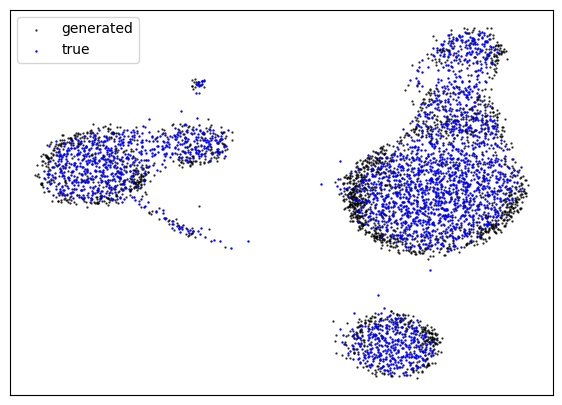

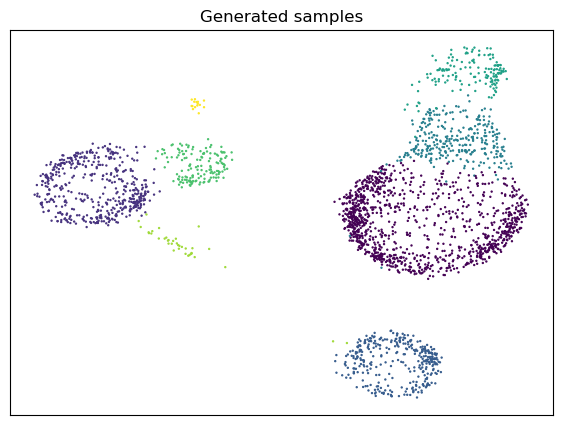

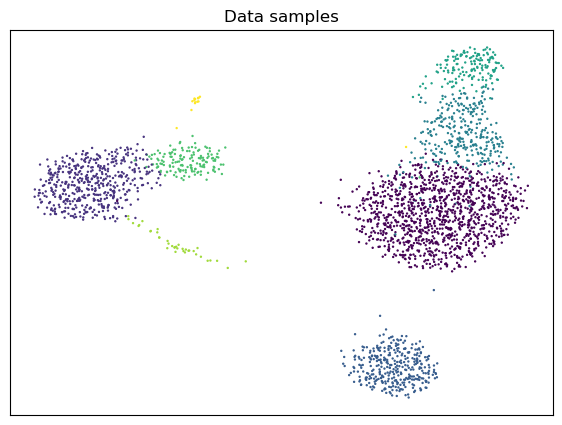

In [9]:
x1, cond = prepare_val_batch(X, C, cond_dim, device)
# x1, cond = train_dataloader.dataset[:]
generated_samples = model.run_simulation(x1.to(device), cond.to(device), n_steps=100)

model.get_umap_reducer()
data_umap = model.reducer.fit_transform(x1.cpu().numpy())
generated_umap = model.reducer.transform(generated_samples.cpu().numpy())

plot_simulation(generated_umap, data_umap,
                np.argmax(cond.cpu().numpy(), axis=1),
                size=0.5, plot_size=(7, 5))

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


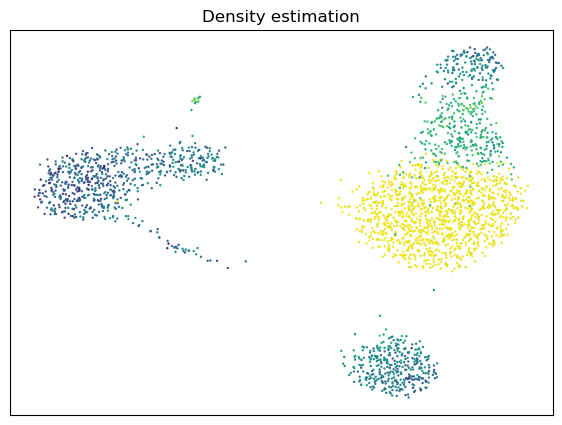

In [45]:
condition = 0
x1, cond = prepare_val_batch(X, C, cond_dim, device)
# x1, cond = train_dataloader.dataset[:]
cond = torch.from_numpy(np.array([1 if i == condition else 0 for i in range(cond_dim)]).reshape(1, -1)
                                ).float().expand(x1.shape[0], cond_dim).to(device)
log_density = model.estimate_log_density(x1.to(device), cond, n_steps=100)

model.get_umap_reducer()
data_umap = model.reducer.fit_transform(x1.cpu().numpy())

plot_densities(data_umap, log_density, size=0.5, plot_size=(7, 5))

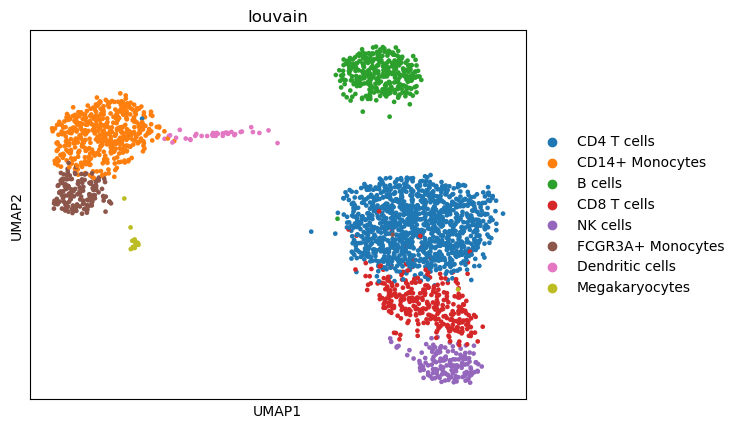

In [24]:
sc.pl.umap(adata, color="louvain")

  0%|          | 0/8 [00:00<?, ?it/s]

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


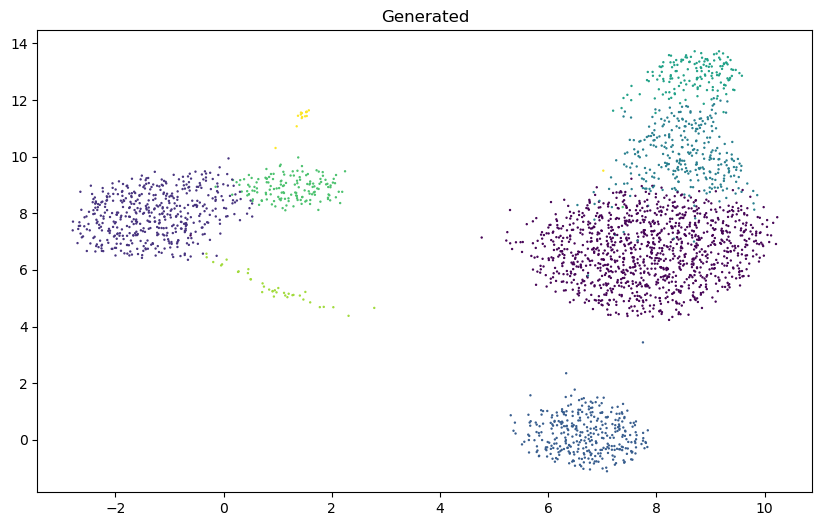

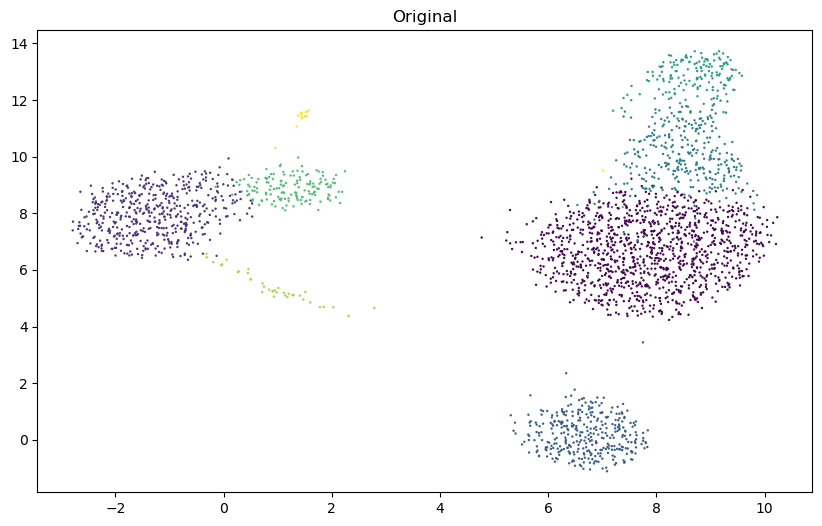

In [26]:
log_density = []
x1, cond_orig = prepare_val_batch(X, C, cond_dim, device)
for condition in tqdm(range(8)):
    cond = torch.from_numpy(np.array([1 if i == condition else 0 for i in range(cond_dim)]).reshape(1, -1)
                                    ).float().expand(x1.shape[0], cond_dim).to(device)
    log_density.append(model.estimate_log_density(x1.to(device), cond, n_steps=100).reshape(-1, 1))
log_density = np.concatenate(log_density, axis=1)
color = np.argmax(log_density, axis=1)

model.get_umap_reducer()
data_umap = model.reducer.fit_transform(x1.cpu().numpy())

plt.figure(figsize=(10, 6))
plt.title("Generated")
plt.scatter(data_umap[:, 0], data_umap[:, 1], s=0.5, c=color)
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Original")
plt.scatter(data_umap[:, 0], data_umap[:, 1], s=0.5, c=np.argmax(cond_orig.cpu().numpy(), axis=1))
plt.show()

In [49]:
log_density = []
x1, cond_orig = prepare_val_batch(X, C, cond_dim, device)
for condition in tqdm(range(8)):
    cond = torch.from_numpy(np.array([1 if i == condition else 0 for i in range(cond_dim)]).reshape(1, -1)
                                    ).float().expand(x1.shape[0], cond_dim).to(device)
    log_density.append(model.estimate_log_density(x1.to(device), cond, n_steps=100).reshape(-1, 1))
log_density = np.concatenate(log_density, axis=1)

  0%|          | 0/8 [00:00<?, ?it/s]

In [50]:
log_density

array([[ -12.612526, -183.51326 , -480.97226 , ..., -236.9715  ,
        -742.4676  , -359.0296  ],
       [-363.3453  , -289.42477 ,  -17.112774, ..., -226.87253 ,
        -299.81042 , -330.864   ],
       [ -17.249573, -266.72797 , -272.81116 , ..., -266.4218  ,
        -286.16476 , -463.10046 ],
       ...,
       [-282.7414  , -429.80582 ,  -15.653423, ..., -341.75418 ,
        -445.1062  , -409.57037 ],
       [-441.6069  , -402.7387  ,  -19.622158, ..., -335.09097 ,
        -422.90753 , -405.16708 ],
       [  -2.188774, -262.68137 , -495.51172 , ..., -293.70114 ,
        -376.89035 , -303.66595 ]], dtype=float32)

In [51]:
np.max(log_density)

7.6082916

In [52]:
np.mean(log_density)

-350.34262

In [53]:
np.mean(np.max(log_density, axis=1))

-18.512394

In [56]:
np.sum(np.max(log_density, axis=1) < 0) / log_density.shape[0]

0.9893858984078847